# M2.4 — Phân tích phân bố từng feature giao dịch

## Mục tiêu

Sau khi M2.3 đã làm rõ target và sự thay đổi theo thời gian, M2.4 chuyển sang khảo sát từng nhóm feature của giao dịch. <br>

Câu hỏi trung tâm của bước này là: <br>
`Một transaction điển hình trong dataset có đặc điểm như thế nào nếu chưa xét đến target?` <br>

Các nhóm feature được khảo sát gồm: <br>
- `Amount` — phân bố giá trị giao dịch; <br>
- `Use Chip` — phân bố hình thức giao dịch; <br>
- `MCC` — phân bố merchant category; <br>
- các biến dẫn xuất từ thời gian — `hour_of_day`, `day_of_week`, `month`; <br>
- các trường location — `Merchant City`, `Merchant State`, `Zip`. <br>

## Logic phân tích

M2.4 thực hiện `EDA đơn biến`. <br>

Tức là trước tiên trả lời: <br>
`feature tự nó phân bố như thế nào?` <br>

Chưa trả lời: <br>
`feature này liên quan đến fraud như thế nào?` <br>

Quan hệ `feature ↔ target` được dành cho M2.6. <br>

## Ranh giới

Trong M2.4: <br>
- chưa sử dụng `Is Fraud?` để so sánh các nhóm feature; <br>
- chưa xử lý Amount âm hoặc Amount bằng 0; <br>
- chưa xử lý missing location; <br>
- chưa xóa outlier; <br>
- chưa encoding category; <br>
- chưa quyết định feature cuối cùng; <br>
- chưa quyết định preprocessing. <br>

`Mục tiêu của M2.4 là hiểu hình dạng và cấu trúc feature trước khi quyết định phải điều tra sâu ở đâu.`

## Thiết lập môi trường thực thi

Notebook này được thiết kế để `chạy độc lập`, không phụ thuộc kernel hoặc biến đã được tạo trong M2.1–M2.3. <br>

Do dataset có hơn 24 triệu transaction, M2.4 sử dụng hai phạm vi dữ liệu: <br>

`Full scan` <br>
→ dùng cho count, frequency, min, max, mean và các bảng tổng hợp cần độ chính xác toàn dataset. <br>

`Mẫu 1% có thể tái hiện` <br>
→ chỉ dùng cho quantile xấp xỉ và trực quan hóa phân bố Amount. <br>

Mọi output sử dụng sample phải được ghi rõ là sample, không được trình bày như population statistic chính xác. <br>

In [26]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# Xác định thư mục gốc của project
# ============================================================

DATA_RELATIVE_PATH = (
    Path("data")
    / "raw"
    / "ibm_tabformer"
    / "card_transaction.v1.csv"
)

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

PROJECT_ROOT = None

for candidate in candidate_roots:
    candidate = candidate.resolve()

    if (
        candidate
        / DATA_RELATIVE_PATH
    ).exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Không xác định được PROJECT_ROOT. "
        "Không tìm thấy file dữ liệu tại đường dẫn kỳ vọng."
    )


# ============================================================
# Các biến dùng chung trong M2.4
# ============================================================

DATA_PATH = (
    PROJECT_ROOT
    / DATA_RELATIVE_PATH
)

CHUNK_SIZE = 500_000

RANDOM_STATE = 42

AMOUNT_SAMPLE_FRAC = 0.01


# ============================================================
# Kiểm tra nhanh
# ============================================================

print("PROJECT_ROOT:")
print(PROJECT_ROOT)

print("\nDATA_PATH:")
print(DATA_PATH)

print("\nFile tồn tại:")
print(DATA_PATH.exists())

print(
    "\nTỷ lệ sample Amount:",
    AMOUNT_SAMPLE_FRAC,
)

PROJECT_ROOT:
/Users/minhtoan/SE/HocTrenLop/Trí tuệ nhân tạo/fraud-risk-screening

DATA_PATH:
/Users/minhtoan/SE/HocTrenLop/Trí tuệ nhân tạo/fraud-risk-screening/data/raw/ibm_tabformer/card_transaction.v1.csv

File tồn tại:
True

Tỷ lệ sample Amount: 0.01


### Nhận xét thiết lập môi trường

Notebook đã xác định được đúng `PROJECT_ROOT` và đường dẫn tới raw artifact. <br>

Kết quả `File tồn tại: True` xác nhận M2.4 có thể truy cập trực tiếp dataset và chạy độc lập, không phụ thuộc vào kernel hoặc các biến đã được tạo trong M2.1–M2.3. <br>

M2.4 sử dụng `CHUNK_SIZE = 500,000` để quét dataset theo từng phần và `AMOUNT_SAMPLE_FRAC = 0.01` để lấy mẫu Amount phục vụ quantile và trực quan hóa. <br>

`Kết luận: PASS`

## M2.4.1 — Quét toàn bộ feature và tạo dữ liệu tổng hợp

### Câu hỏi

Có thể thu thập các thống kê đơn biến cần thiết của M2.4 chỉ bằng `một lần full scan` hay không? <br>

### Phương pháp

Đọc dataset theo từng chunk và chỉ lấy các cột cần cho M2.4: <br>
`Year` <br>
`Month` <br>
`Day` <br>
`Time` <br>
`Amount` <br>
`Use Chip` <br>
`MCC` <br>
`Merchant City` <br>
`Merchant State` <br>
`Zip` <br>

Trong cùng một lần quét sẽ thu thập: <br>
- thống kê số cơ bản của Amount; <br>
- số Amount âm / bằng 0 / dương để làm bằng chứng ban đầu; <br>
- sample 1% của Amount phục vụ quantile và biểu đồ; <br>
- frequency của Use Chip; <br>
- frequency của MCC; <br>
- frequency theo giờ, thứ trong tuần và tháng; <br>
- frequency của các trường location. <br>

Việc giải thích Amount âm / bằng 0 sẽ được để cho M2.5. <br>
Missingness của location cũng được dành cho M2.5. <br>

In [27]:
M24_USECOLS = [
    "Year",
    "Month",
    "Day",
    "Time",
    "Amount",
    "Use Chip",
    "MCC",
    "Merchant City",
    "Merchant State",
    "Zip",
]


def parse_amount(amount_series):
    cleaned = (
        amount_series
        .astype("string")
        .str.replace(
            "$",
            "",
            regex=False,
        )
        .str.replace(
            ",",
            "",
            regex=False,
        )
        .str.strip()
    )

    return pd.to_numeric(
        cleaned,
        errors="coerce",
    )


# ============================================================
# Biến tổng hợp
# ============================================================

total_rows = 0
chunk_count = 0


# Amount
amount_count = 0
amount_sum = 0.0
amount_sum_of_squares = 0.0

amount_min = None
amount_max = None

amount_negative_count = 0
amount_zero_count = 0
amount_positive_count = 0

amount_sample_parts = []


# Category / temporal frequency
use_chip_counts = Counter()

mcc_counts = Counter()

hour_counts = Counter()
day_of_week_counts = Counter()
month_counts = Counter()

merchant_city_counts = Counter()
merchant_state_counts = Counter()
zip_counts = Counter()


# ============================================================
# Full scan
# ============================================================

for chunk_number, chunk in enumerate(
    pd.read_csv(
        DATA_PATH,
        usecols=M24_USECOLS,
        chunksize=CHUNK_SIZE,
    ),
    start=1,
):
    chunk_count = chunk_number
    total_rows += len(chunk)

    # --------------------------------------------------------
    # Amount
    # --------------------------------------------------------

    amount_numeric = parse_amount(
        chunk["Amount"]
    )

    valid_amount = (
        amount_numeric
        .dropna()
    )

    amount_count += len(
        valid_amount
    )

    amount_sum += float(
        valid_amount.sum()
    )

    amount_sum_of_squares += float(
        np.square(
            valid_amount.to_numpy(
                dtype="float64"
            )
        ).sum()
    )

    if not valid_amount.empty:
        chunk_min = float(
            valid_amount.min()
        )

        chunk_max = float(
            valid_amount.max()
        )

        if (
            amount_min is None
            or chunk_min < amount_min
        ):
            amount_min = chunk_min

        if (
            amount_max is None
            or chunk_max > amount_max
        ):
            amount_max = chunk_max

    amount_negative_count += int(
        (valid_amount < 0).sum()
    )

    amount_zero_count += int(
        (valid_amount == 0).sum()
    )

    amount_positive_count += int(
        (valid_amount > 0).sum()
    )

    # Mẫu 1% dùng cho quantile / visualization
    amount_sample_parts.append(
        valid_amount.sample(
            frac=AMOUNT_SAMPLE_FRAC,
            random_state=(
                RANDOM_STATE
                + chunk_number
            ),
        )
    )

    # --------------------------------------------------------
    # Use Chip
    # --------------------------------------------------------

    use_chip_counts.update(
        chunk["Use Chip"]
        .dropna()
        .value_counts()
        .to_dict()
    )

    # --------------------------------------------------------
    # MCC
    # --------------------------------------------------------

    mcc_counts.update(
        chunk["MCC"]
        .dropna()
        .value_counts()
        .to_dict()
    )

    # --------------------------------------------------------
    # Hour of day
    # --------------------------------------------------------

    hour = pd.to_numeric(
        chunk["Time"]
        .astype("string")
        .str.slice(0, 2),
        errors="coerce",
    )

    hour_counts.update(
        hour
        .dropna()
        .astype(int)
        .value_counts()
        .to_dict()
    )

    # --------------------------------------------------------
    # Day of week
    # --------------------------------------------------------

    transaction_date = pd.to_datetime(
        {
            "year":
                chunk["Year"],

            "month":
                chunk["Month"],

            "day":
                chunk["Day"],
        },
        errors="coerce",
    )

    day_of_week = (
        transaction_date
        .dt.dayofweek
    )

    day_of_week_counts.update(
        day_of_week
        .dropna()
        .astype(int)
        .value_counts()
        .to_dict()
    )

    # --------------------------------------------------------
    # Month
    # --------------------------------------------------------

    month_counts.update(
        chunk["Month"]
        .dropna()
        .value_counts()
        .to_dict()
    )

    # --------------------------------------------------------
    # Location
    # --------------------------------------------------------

    merchant_city_counts.update(
        chunk["Merchant City"]
        .dropna()
        .value_counts()
        .to_dict()
    )

    merchant_state_counts.update(
        chunk["Merchant State"]
        .dropna()
        .value_counts()
        .to_dict()
    )

    zip_counts.update(
        chunk["Zip"]
        .dropna()
        .value_counts()
        .to_dict()
    )

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        chunk_number % 10 == 0
        or len(chunk) < CHUNK_SIZE
    ):
        print(
            f"Đã xử lý {chunk_number} chunk "
            f"- tổng số dòng: {total_rows:,}"
        )


# ============================================================
# Ghép sample Amount
# ============================================================

amount_sample = pd.concat(
    amount_sample_parts,
    ignore_index=True,
)


print("\nHoàn tất quét M2.4.")
print("Số chunk:", chunk_count)
print(
    "Tổng số dòng:",
    f"{total_rows:,}",
)

print(
    "Số Amount trong sample:",
    f"{len(amount_sample):,}",
)

aggregation_integrity_checks = pd.Series(
    {
        "Use Chip count = total rows":
            sum(
                use_chip_counts.values()
            )
            == total_rows,

        "MCC count = total rows":
            sum(
                mcc_counts.values()
            )
            == total_rows,

        "Hour count = total rows":
            sum(
                hour_counts.values()
            )
            == total_rows,

        "Day-of-week count = total rows":
            sum(
                day_of_week_counts.values()
            )
            == total_rows,

        "Month count = total rows":
            sum(
                month_counts.values()
            )
            == total_rows,

        "Merchant City count = total rows":
            sum(
                merchant_city_counts.values()
            )
            == total_rows,
    }
)


print(
    "\nKiểm tra tính toàn vẹn "
    "của các phép tổng hợp:"
)

display(
    aggregation_integrity_checks
)

Đã xử lý 10 chunk - tổng số dòng: 5,000,000
Đã xử lý 20 chunk - tổng số dòng: 10,000,000
Đã xử lý 30 chunk - tổng số dòng: 15,000,000
Đã xử lý 40 chunk - tổng số dòng: 20,000,000
Đã xử lý 49 chunk - tổng số dòng: 24,386,900

Hoàn tất quét M2.4.
Số chunk: 49
Tổng số dòng: 24,386,900
Số Amount trong sample: 243,869

Kiểm tra tính toàn vẹn của các phép tổng hợp:


Use Chip count = total rows         True
MCC count = total rows              True
Hour count = total rows             True
Day-of-week count = total rows      True
Month count = total rows            True
Merchant City count = total rows    True
dtype: bool

### Nhận xét M2.4.1

Toàn bộ dataset đã được quét thành công qua `49 chunk`, với tổng cộng `24,386,900 transaction`. <br>

Mẫu Amount chứa `243,869 giá trị`, tương ứng xấp xỉ `1%` toàn dataset như thiết kế. <br>

Các phép kiểm tra tính toàn vẹn đều trả về `True`: <br>
`Use Chip count = total rows` <br>
`MCC count = total rows` <br>
`Hour count = total rows` <br>
`Day-of-week count = total rows` <br>
`Month count = total rows` <br>
`Merchant City count = total rows` <br>

Điều này cho thấy các phép tổng hợp chính của M2.4 không làm thất thoát transaction đối với những trường không có missing được kiểm tra tại bước này. <br>

Việc thu thập Amount, category, time và location trong cùng một full scan giúp hạn chế việc phải đọc lại file hơn 24 triệu dòng nhiều lần. <br>

`Kết luận: PASS`

## M2.4.2 — Phân bố Amount

### Vì sao kiểm tra này tồn tại?

`Amount` là feature numerical trực tiếp quan trọng nhất của transaction. <br>

Đối với một biến số, bước đầu tiên cần hiểu: <br>
- mức trung tâm; <br>
- độ phân tán; <br>
- khoảng giá trị; <br>
- độ lệch của distribution; <br>
- phần đuôi có dài hay không; <br>
- có nhóm giá trị đặc biệt cần điều tra riêng hay không. <br>

### Câu hỏi

Amount điển hình nằm ở khoảng nào? <br>

Mean và median có cách xa nhau không? <br>

Phân bố có bị lệch mạnh hay có đuôi dài không? <br>

Min / max cách xa phần lớn transaction đến mức nào? <br>

### Phương pháp

Các thống kê sau được tính chính xác từ `full scan`: <br>
- count; <br>
- min; <br>
- max; <br>
- mean; <br>
- standard deviation; <br>
- số Amount âm / bằng 0 / dương. <br>

Các `quantile` được ước lượng từ `sample 1% có thể tái hiện`. <br>

Amount âm và Amount bằng 0 chỉ được ghi nhận ở đây. <br>
Ý nghĩa và cách xử lý của chúng được dành cho M2.5. <br>

In [28]:
amount_mean = (
    amount_sum
    / amount_count
)

amount_variance = max(
    (
        amount_sum_of_squares
        / amount_count
    )
    - amount_mean ** 2,
    0.0,
)

amount_std = np.sqrt(
    amount_variance
)


amount_full_summary = pd.Series(
    {
        "count":
            amount_count,

        "min":
            amount_min,

        "max":
            amount_max,

        "mean":
            amount_mean,

        "std":
            amount_std,

        "negative_count":
            amount_negative_count,

        "negative_rate_pct":
            (
                amount_negative_count
                / amount_count
                * 100
            ),

        "zero_count":
            amount_zero_count,

        "zero_rate_pct":
            (
                amount_zero_count
                / amount_count
                * 100
            ),

        "positive_count":
            amount_positive_count,

        "positive_rate_pct":
            (
                amount_positive_count
                / amount_count
                * 100
            ),
    }
)


print(
    "Thống kê chính xác từ full dataset:"
)
display(
    amount_full_summary
)


amount_quantiles = (
    amount_sample
    .quantile(
        [
            0.001,
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
            0.999,
        ]
    )
    .rename(
        "Amount"
    )
)


print(
    "\nQuantile xấp xỉ từ sample 1%:"
)
display(
    amount_quantiles
)

Thống kê chính xác từ full dataset:


count                2.438690e+07
min                 -5.000000e+02
max                  1.239050e+04
mean                 4.363401e+01
std                  8.202239e+01
negative_count       1.244683e+06
negative_rate_pct    5.103900e+00
zero_count           2.021300e+04
zero_rate_pct        8.288466e-02
positive_count       2.312200e+07
positive_rate_pct    9.481322e+01
dtype: float64


Quantile xấp xỉ từ sample 1%:


0.001      -438.0
0.010       -96.0
0.050       -51.0
0.250        9.17
0.500       30.21
0.750       65.26
0.950     147.646
0.990    320.8356
0.999    894.7498
Name: Amount, dtype: Float64

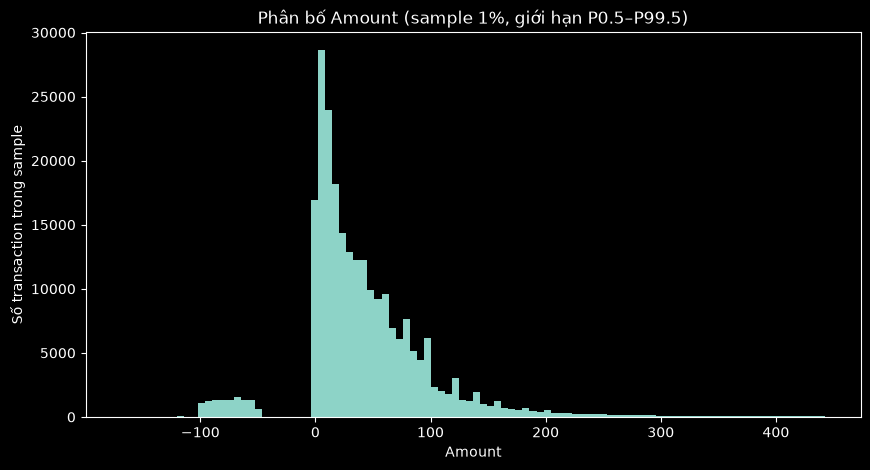

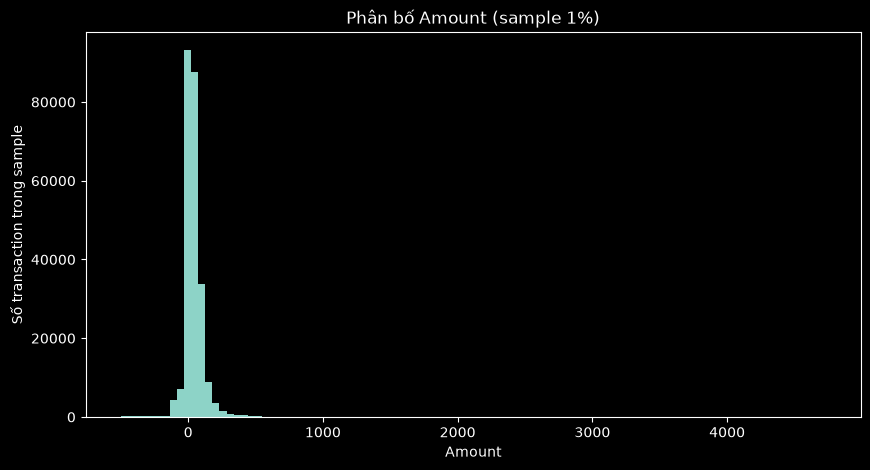

In [29]:
lower_bound = (
    amount_sample
    .quantile(0.005)
)

upper_bound = (
    amount_sample
    .quantile(0.995)
)


amount_for_plot = (
    amount_sample[
        amount_sample.between(
            lower_bound,
            upper_bound,
        )
    ]
)


plt.figure(
    figsize=(10, 5)
)

plt.hist(
    amount_for_plot,
    bins=100,
)

plt.xlabel(
    "Amount"
)

plt.ylabel(
    "Số transaction trong sample"
)

plt.title(
    "Phân bố Amount "
    "(sample 1%, giới hạn P0.5–P99.5)"
)

plt.show()


plt.figure(
    figsize=(10, 5)
)

plt.hist(
    amount_sample,
    bins=100,
)

plt.xlabel(
    "Amount"
)

plt.ylabel(
    "Số transaction trong sample"
)

plt.title(
    "Phân bố Amount "
    "(sample 1%)"
)

plt.show()

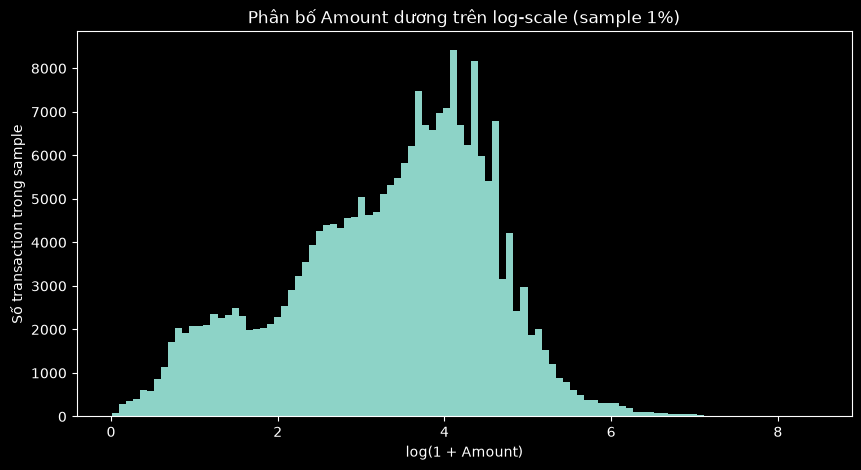

In [30]:
positive_amount_sample = (
    amount_sample[
        amount_sample > 0
    ]
)


plt.figure(
    figsize=(10, 5)
)

plt.hist(
    np.log1p(
        positive_amount_sample
    ),
    bins=100,
)

plt.xlabel(
    "log(1 + Amount)"
)

plt.ylabel(
    "Số transaction trong sample"
)

plt.title(
    "Phân bố Amount dương trên log-scale "
    "(sample 1%)"
)

plt.show()

### Nhận xét M2.4.2

Amount có khoảng giá trị rất rộng: <br>
`min = -500.00` <br>
`max = 12,390.50` <br>
`mean ≈ 43.63` <br>
`standard deviation ≈ 82.02` <br>

Median xấp xỉ từ sample 1% là `30.21`, thấp hơn đáng kể so với mean `43.63`. <br>

Các quantile từ sample cho thấy phần lớn transaction nằm ở vùng giá trị tương đối thấp: <br>
`P25 ≈ 9.17` <br>
`P50 ≈ 30.21` <br>
`P75 ≈ 65.26` <br>
`P95 ≈ 147.65` <br>
`P99 ≈ 320.84` <br>
`P99.9 ≈ 894.75` <br>

Trong khi đó giá trị cực đại của toàn dataset lên tới `12,390.50`, lớn hơn rất nhiều so với ngay cả P99.9. <br>

Biểu đồ toàn range cho thấy phần lớn transaction tập trung trong một vùng hẹp so với miền giá trị tổng thể, trong khi một số Amount rất lớn tạo ra phần đuôi kéo dài về phía dương. <br>

Biểu đồ zoom vùng trung tâm làm rõ hơn khối lượng transaction tập trung quanh các Amount nhỏ và vừa. <br>

Biểu đồ `log(1 + Amount)` đối với Amount dương giúp trải phần phân bố dương ra để quan sát rõ hơn, nhưng distribution vẫn có cấu trúc và không trở thành một phân bố đối xứng đơn giản. <br>

Về dấu của Amount: <br>
`Amount âm: 1,244,683 — khoảng 5.10%` <br>
`Amount bằng 0: 20,213 — khoảng 0.083%` <br>
`Amount dương: 23,122,004 — khoảng 94.81%` <br>

Tỷ lệ Amount âm hơn `5%` là đủ lớn để không thể xem như một vài lỗi nhập liệu ngẫu nhiên. <br>

Tuy nhiên M2.4 chưa có bằng chứng để kết luận ý nghĩa nghiệp vụ của Amount âm hoặc quyết định sửa chúng. <br>

Các Amount bằng 0 cũng được ghi nhận nhưng chưa xử lý. <br>

`Kết luận: Amount có phân bố lệch mạnh, tail dương dài và tồn tại một nhóm Amount âm đáng kể; các nhóm giá trị đặc biệt này cần được điều tra riêng ở M2.5 trước khi quyết định preprocessing.`

## M2.4.3 — Phân bố hình thức giao dịch Use Chip

### Vì sao kiểm tra này tồn tại?

`Use Chip` là feature categorical có ba category rõ nghĩa nghiệp vụ. <br>

Với categorical feature, câu hỏi đầu tiên không phải mean hay median mà là: <br>
`mỗi category xuất hiện bao nhiêu và có category nào chi phối dataset hay không?` <br>

### Câu hỏi

Ba hình thức giao dịch phân bố như thế nào? <br>

Một category có chiếm phần lớn dataset hay các nhóm tương đối cân bằng? <br>

### Phương pháp

Sử dụng frequency thu được từ full scan để tính: <br>
- transaction count; <br>
- tỷ lệ trên toàn dataset. <br>

M2.4 chưa so sánh fraud rate giữa các nhóm. <br>
Quan hệ `Use Chip ↔ fraud` được dành cho M2.6. <br>

In [31]:
use_chip_df = pd.DataFrame(
    [
        {
            "Use Chip": value,
            "transaction_count": count,
        }
        for value, count
        in use_chip_counts.items()
    ]
)


use_chip_df[
    "transaction_share_pct"
] = (
    use_chip_df[
        "transaction_count"
    ]
    / total_rows
    * 100
)


use_chip_df = (
    use_chip_df
    .sort_values(
        "transaction_count",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    use_chip_df
)

,Use Chip,transaction_count,transaction_share_pct
0,Swipe Transaction,15386082,63.091586
1,Chip Transaction,6287598,25.782687
2,Online Transaction,2713220,11.125727


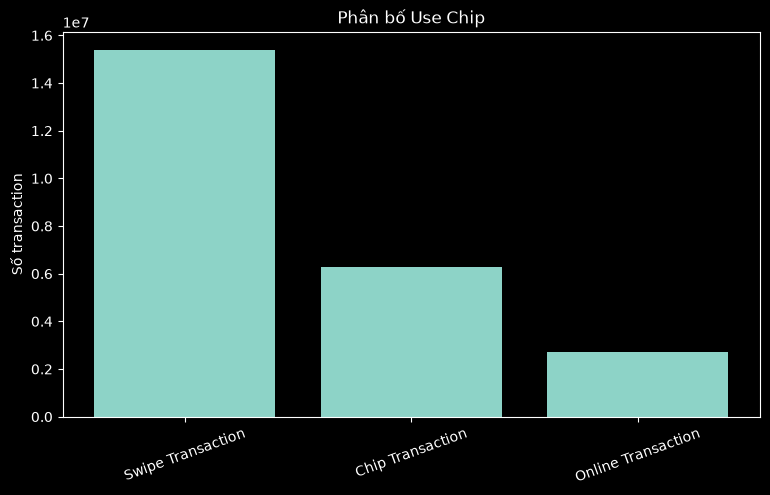

In [32]:
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    use_chip_df[
        "Use Chip"
    ],
    use_chip_df[
        "transaction_count"
    ],
)

plt.ylabel(
    "Số transaction"
)

plt.title(
    "Phân bố Use Chip"
)

plt.xticks(
    rotation=20,
)

plt.show()

### Nhận xét M2.4.3

`Use Chip` có đúng ba category và cả ba đều có số lượng transaction đáng kể. <br>

Phân bố cụ thể: <br>
`Swipe Transaction: 15,386,082 — 63.09%` <br>
`Chip Transaction: 6,287,598 — 25.78%` <br>
`Online Transaction: 2,713,220 — 11.13%` <br>

Dataset không cân bằng giữa ba hình thức giao dịch. <br>

`Swipe Transaction` chiếm gần hai phần ba toàn bộ transaction và là category chi phối rõ rệt. <br>

`Chip Transaction` đứng thứ hai với khoảng một phần tư dataset. <br>

`Online Transaction` nhỏ nhất nhưng vẫn gồm hơn `2.7 triệu transaction`, nên không phải một category hiếm ở mức có thể bỏ qua. <br>

Ở M2.4 chỉ có thể kết luận sự khác biệt về mức phổ biến giữa ba nhóm. <br>

Chưa có bằng chứng tại bước này để nói nhóm nào có rủi ro fraud cao hơn. <br>

`Online Transaction` cần được giữ lại để đối chiếu với cấu trúc missing của location ở M2.5. <br>

`Kết luận: Use Chip có ba category với mức hỗ trợ lớn nhưng phân bố không cân bằng; Swipe là hình thức chủ đạo, còn Online tuy nhỏ hơn nhưng vẫn có quy mô rất đáng kể.`

## M2.4.4 — Phân bố Merchant Category Code

### Vì sao kiểm tra này tồn tại?

`MCC` được lưu dưới dạng số nhưng về ý nghĩa là `categorical code`. <br>

Do đó không tính mean hoặc standard deviation của MCC như một numerical feature. <br>

Câu hỏi phù hợp là về `frequency` và `độ tập trung của category`. <br>

### Câu hỏi

Có bao nhiêu MCC thực tế? <br>

Transaction có tập trung vào một số ít MCC hay phân bố tương đối đều? <br>

Có xuất hiện cấu trúc `long-tail` — một số MCC rất phổ biến và nhiều MCC ít gặp — hay không? <br>

### Phương pháp

Từ full scan, tạo bảng: <br>
`MCC → transaction_count → transaction_share_pct → cumulative_share_pct` <br>

Đồng thời xác định số MCC tối thiểu cần để bao phủ lần lượt `50%`, `80%`, `90%` và `95%` toàn bộ transaction. <br>

M2.4 chưa xét fraud rate theo MCC. <br>
Phần đó thuộc M2.6, nơi transaction support phải được xem cùng fraud rate. <br>

In [33]:
mcc_frequency_df = pd.DataFrame(
    [
        {
            "MCC": mcc,
            "transaction_count": count,
        }
        for mcc, count
        in mcc_counts.items()
    ]
)


mcc_frequency_df = (
    mcc_frequency_df
    .sort_values(
        "transaction_count",
        ascending=False,
    )
    .reset_index(drop=True)
)


mcc_frequency_df[
    "transaction_share_pct"
] = (
    mcc_frequency_df[
        "transaction_count"
    ]
    / total_rows
    * 100
)


mcc_frequency_df[
    "cumulative_share_pct"
] = (
    mcc_frequency_df[
        "transaction_share_pct"
    ]
    .cumsum()
)


def categories_needed_for_share(
    frequency_df,
    target_share_pct,
):
    mask = (
        frequency_df[
            "cumulative_share_pct"
        ]
        >= target_share_pct
    )

    if not mask.any():
        return len(frequency_df)

    return int(
        mask.idxmax()
        + 1
    )


mcc_support_summary = pd.Series(
    {
        "unique_mcc":
            len(
                mcc_frequency_df
            ),

        "min_transaction_count":
            int(
                mcc_frequency_df[
                    "transaction_count"
                ].min()
            ),

        "median_transaction_count":
            float(
                mcc_frequency_df[
                    "transaction_count"
                ].median()
            ),

        "mean_transaction_count":
            float(
                mcc_frequency_df[
                    "transaction_count"
                ].mean()
            ),

        "max_transaction_count":
            int(
                mcc_frequency_df[
                    "transaction_count"
                ].max()
            ),

        "mcc_needed_for_50pct":
            categories_needed_for_share(
                mcc_frequency_df,
                50,
            ),

        "mcc_needed_for_80pct":
            categories_needed_for_share(
                mcc_frequency_df,
                80,
            ),

        "mcc_needed_for_90pct":
            categories_needed_for_share(
                mcc_frequency_df,
                90,
            ),

        "mcc_needed_for_95pct":
            categories_needed_for_share(
                mcc_frequency_df,
                95,
            ),
    }
)


display(
    mcc_support_summary
)


print(
    "Tóm tắt support của MCC:"
)
display(
    mcc_support_summary
)


MCC_TOP_PREVIEW_N = min(
    15,
    len(mcc_frequency_df),
)

MCC_BOTTOM_PREVIEW_N = min(
    10,
    len(mcc_frequency_df),
)


print(
    f"\n{MCC_TOP_PREVIEW_N} MCC "
    "phổ biến nhất:"
)

display(
    mcc_frequency_df.head(
        MCC_TOP_PREVIEW_N
    )
)


print(
    f"\n{MCC_BOTTOM_PREVIEW_N} MCC "
    "ít xuất hiện nhất:"
)

display(
    mcc_frequency_df.tail(
        MCC_BOTTOM_PREVIEW_N
    )
)

unique_mcc                  1.090000e+02
min_transaction_count       4.960000e+02
median_transaction_count    2.631600e+04
mean_transaction_count      2.237330e+05
max_transaction_count       2.860738e+06
mcc_needed_for_50pct        6.000000e+00
mcc_needed_for_80pct        1.500000e+01
mcc_needed_for_90pct        2.300000e+01
mcc_needed_for_95pct        3.400000e+01
dtype: float64

Tóm tắt support của MCC:


unique_mcc                  1.090000e+02
min_transaction_count       4.960000e+02
median_transaction_count    2.631600e+04
mean_transaction_count      2.237330e+05
max_transaction_count       2.860738e+06
mcc_needed_for_50pct        6.000000e+00
mcc_needed_for_80pct        1.500000e+01
mcc_needed_for_90pct        2.300000e+01
mcc_needed_for_95pct        3.400000e+01
dtype: float64


15 MCC phổ biến nhất:


,MCC,transaction_count,transaction_share_pct,cumulative_share_pct
0,5411,2860738,11.730634,11.730634
1,5499,2680609,10.992004,22.722638
2,5541,2638982,10.821310,33.543948
3,5812,1797920,7.372483,40.916431
4,5912,1407636,5.772099,46.688529
5,4829,1129061,4.629785,51.318314
6,4784,1124291,4.610225,55.928540
7,5300,1123037,4.605083,60.533623
8,4121,981523,4.024796,64.558419
9,7538,914630,3.750497,68.308916



10 MCC ít xuất hiện nhất:


,MCC,transaction_count,transaction_share_pct,cumulative_share_pct
99,3009,739,0.003030,99.975798
100,3005,729,0.002989,99.978788
101,3008,714,0.002928,99.981716
102,3006,702,0.002879,99.984594
103,3075,666,0.002731,99.987325
104,3007,666,0.002731,99.990056
105,5722,663,0.002719,99.992775
106,4411,634,0.002600,99.995375
107,3144,632,0.002592,99.997966
108,5733,496,0.002034,100.000000


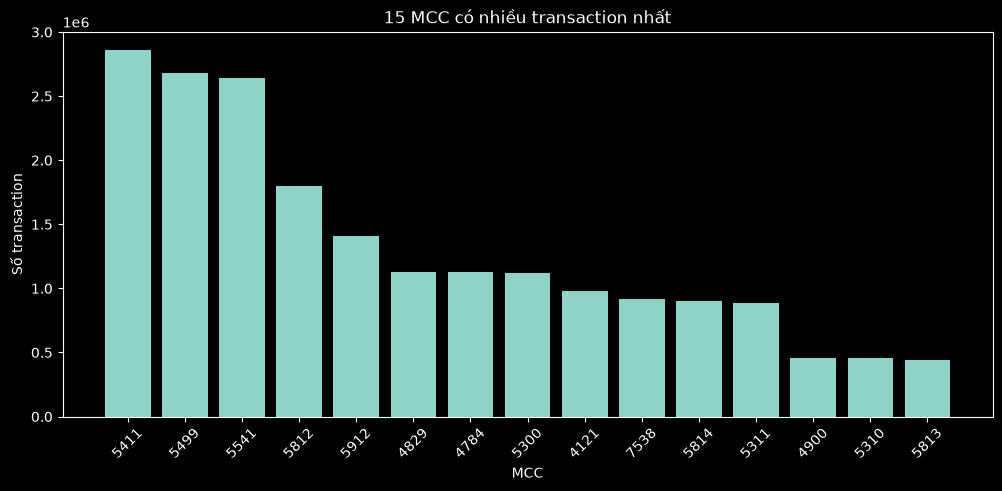

In [34]:
MCC_PLOT_N = min(
    15,
    len(mcc_frequency_df),
)


top_mcc_df = (
    mcc_frequency_df
    .head(
        MCC_PLOT_N
    )
    .copy()
)


plt.figure(
    figsize=(12, 5)
)

plt.bar(
    top_mcc_df[
        "MCC"
    ].astype(str),
    top_mcc_df[
        "transaction_count"
    ],
)

plt.xlabel(
    "MCC"
)

plt.ylabel(
    "Số transaction"
)

plt.title(
    f"{MCC_PLOT_N} MCC "
    "có nhiều transaction nhất"
)

plt.xticks(
    rotation=45,
)

plt.show()

### Nhận xét M2.4.4

Dataset có `109 MCC` khác nhau. <br>

Số transaction giữa các MCC phân bố rất không đồng đều: <br>
`MCC ít nhất: 496 transaction` <br>
`Median: 26,316 transaction` <br>
`Mean: khoảng 223,733 transaction` <br>
`MCC lớn nhất: 2,860,738 transaction` <br>

Mean lớn hơn median rất nhiều cho thấy một số MCC có support cực lớn kéo trung bình lên cao. <br>

Mức độ tập trung thể hiện rõ hơn qua cumulative share: <br>
`6 MCC` đã bao phủ ít nhất `50%` toàn bộ transaction. <br>
`15 MCC` bao phủ ít nhất `80%`. <br>
`23 MCC` bao phủ ít nhất `90%`. <br>
`34 MCC` bao phủ ít nhất `95%`. <br>

Như vậy chỉ khoảng một phần ba số MCC đã bao phủ ít nhất 95% transaction, trong khi phần còn lại tạo thành một tail gồm nhiều category ít phổ biến hơn. <br>

Ba MCC phổ biến nhất là: <br>
`5411: 11.73%` <br>
`5499: 10.99%` <br>
`5541: 10.82%` <br>

Chỉ riêng ba MCC này đã chiếm khoảng `33.54%` toàn dataset. <br>

Ở đầu còn lại, một số MCC chỉ có vài trăm transaction; MCC ít nhất được quan sát có `496 transaction`. <br>

Do đó MCC thể hiện cấu trúc `category concentration + long-tail` rõ rệt. <br>

Khi sang M2.6, fraud rate của từng MCC không được đọc tách rời khỏi `transaction_count`, vì các MCC ở tail có support thấp hơn nhiều so với nhóm phổ biến. <br>

`Kết luận: MCC là categorical feature có mức tập trung cao và long-tail rõ; support giữa các category chênh lệch rất lớn.`

## M2.4.5 — Phân bố giao dịch theo thời gian trong ngày, tuần và năm

### Vì sao kiểm tra này tồn tại?

Timestamp không chỉ cho biết thứ tự giao dịch. <br>

Nó còn cho phép tạo các candidate feature mô tả `khi nào transaction xảy ra`. <br>

Trước khi quyết định dùng những feature đó, cần xem dataset có thực sự chứa pattern thời gian đáng kể hay không. <br>

### Câu hỏi

Transaction phân bố thế nào theo: <br>
- giờ trong ngày; <br>
- thứ trong tuần; <br>
- tháng trong năm? <br>

Có khung thời gian nào chiếm tỷ trọng đặc biệt lớn hoặc nhỏ hay không? <br>

### Ranh giới

M2.3 đã phân tích sự thay đổi theo `Year`, nên không lặp lại tại đây. <br>

M2.4 chỉ khảo sát transaction frequency. <br>

Quan hệ giữa các biến thời gian và fraud được dành cho M2.6. <br>

In [35]:
hour_df = pd.DataFrame(
    {
        "hour":
            list(
                range(24)
            )
    }
)


hour_df[
    "transaction_count"
] = (
    hour_df["hour"]
    .map(hour_counts)
    .fillna(0)
    .astype(int)
)


hour_df[
    "transaction_share_pct"
] = (
    hour_df[
        "transaction_count"
    ]
    / total_rows
    * 100
)


display(
    hour_df
)

,hour,transaction_count,transaction_share_pct
0,0,235608,0.966125
1,1,213411,0.875105
2,2,214075,0.877828
3,3,183370,0.751920
4,4,203550,0.834669
5,5,321588,1.318692
6,6,1347058,5.523695
7,7,1644618,6.743858
8,8,1616851,6.629998
9,9,1598928,6.556504


In [36]:
DAY_NAMES_VI = {
    0: "Thứ Hai",
    1: "Thứ Ba",
    2: "Thứ Tư",
    3: "Thứ Năm",
    4: "Thứ Sáu",
    5: "Thứ Bảy",
    6: "Chủ Nhật",
}


day_of_week_df = pd.DataFrame(
    {
        "day_of_week":
            list(
                range(7)
            )
    }
)


day_of_week_df[
    "day_name"
] = (
    day_of_week_df[
        "day_of_week"
    ]
    .map(
        DAY_NAMES_VI
    )
)


day_of_week_df[
    "transaction_count"
] = (
    day_of_week_df[
        "day_of_week"
    ]
    .map(
        day_of_week_counts
    )
    .fillna(0)
    .astype(int)
)


day_of_week_df[
    "transaction_share_pct"
] = (
    day_of_week_df[
        "transaction_count"
    ]
    / total_rows
    * 100
)


display(
    day_of_week_df
)

,day_of_week,day_name,transaction_count,transaction_share_pct
0,0,Thứ Hai,3480263,14.271035
1,1,Thứ Ba,3468169,14.221443
2,2,Thứ Tư,3475771,14.252615
3,3,Thứ Năm,3495004,14.331481
4,4,Thứ Sáu,3482897,14.281836
5,5,Thứ Bảy,3499591,14.350291
6,6,Chủ Nhật,3485205,14.291300


In [37]:
month_df = pd.DataFrame(
    {
        "Month":
            list(
                range(1, 13)
            )
    }
)


month_df[
    "transaction_count"
] = (
    month_df["Month"]
    .map(
        month_counts
    )
    .fillna(0)
    .astype(int)
)


month_df[
    "transaction_share_pct"
] = (
    month_df[
        "transaction_count"
    ]
    / total_rows
    * 100
)


display(
    month_df
)

,Month,transaction_count,transaction_share_pct
0,1,2142220,8.784306
1,2,1960411,8.038787
2,3,2002867,8.212881
3,4,1941806,7.962496
4,5,2023412,8.297127
5,6,1981230,8.124157
6,7,2051785,8.413472
7,8,2070407,8.489833
8,9,2006307,8.226987
9,10,2075188,8.509437


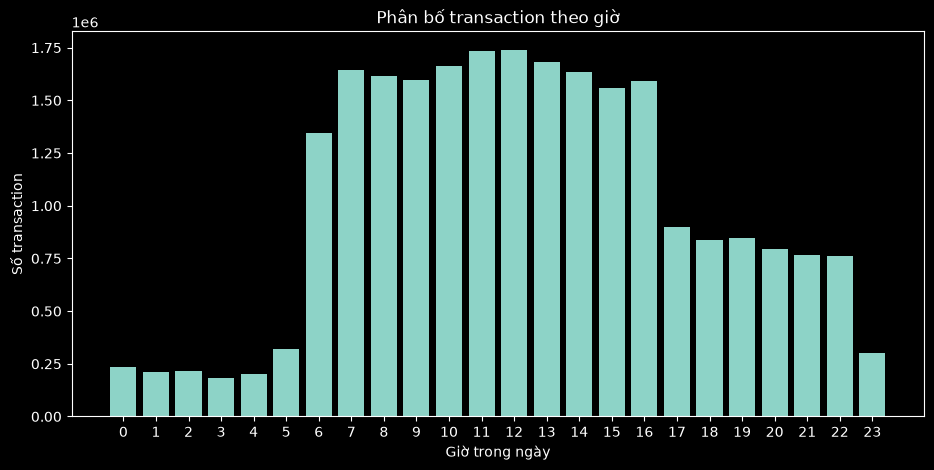

In [38]:
plt.figure(
    figsize=(11, 5)
)

plt.bar(
    hour_df["hour"],
    hour_df[
        "transaction_count"
    ],
)

plt.xlabel(
    "Giờ trong ngày"
)

plt.ylabel(
    "Số transaction"
)

plt.title(
    "Phân bố transaction theo giờ"
)

plt.xticks(
    range(24)
)

plt.show()

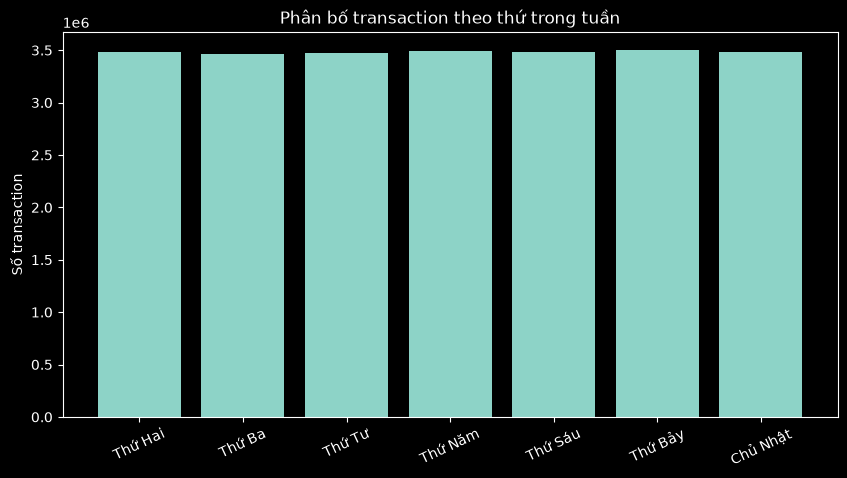

In [39]:
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    day_of_week_df[
        "day_name"
    ],
    day_of_week_df[
        "transaction_count"
    ],
)

plt.ylabel(
    "Số transaction"
)

plt.title(
    "Phân bố transaction theo thứ trong tuần"
)

plt.xticks(
    rotation=25,
)

plt.show()

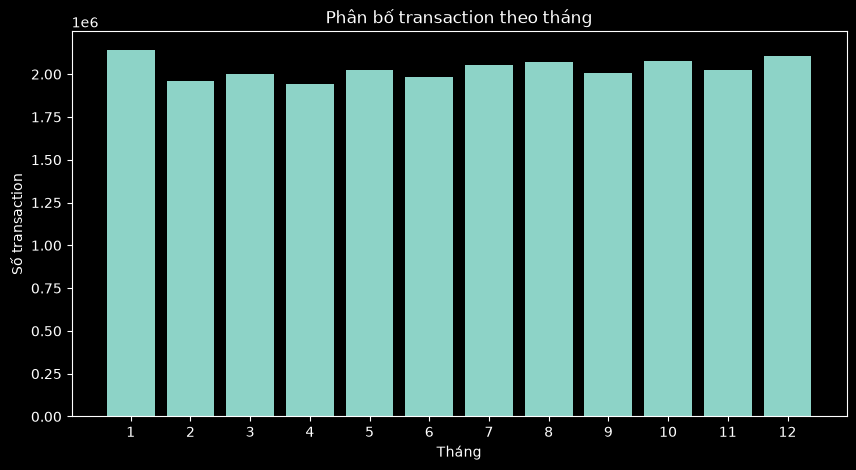

In [40]:
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    month_df[
        "Month"
    ],
    month_df[
        "transaction_count"
    ],
)

plt.xlabel(
    "Tháng"
)

plt.ylabel(
    "Số transaction"
)

plt.title(
    "Phân bố transaction theo tháng"
)

plt.xticks(
    range(1, 13)
)

plt.show()

### Nhận xét M2.4.5

Phân bố theo `hour_of_day` thể hiện pattern trong ngày rất rõ. <br>

Giai đoạn từ `00:00 đến 05:59` có tỷ trọng transaction thấp, mỗi giờ chỉ khoảng `0.75%–1.32%` toàn dataset. <br>

Từ `06:00` số transaction tăng mạnh lên khoảng `5.52%`, sau đó duy trì ở mức cao trong phần lớn thời gian ban ngày. <br>

Khoảng `07:00–16:59` mỗi giờ thường chiếm khoảng `6.4%–7.1%` transaction. <br>

Hai giờ có tỷ trọng cao nhất nằm quanh `11:00–12:59`, đều trên `7.1%`. <br>

Sau `17:00`, số transaction giảm rõ rệt; các giờ buổi tối chủ yếu nằm quanh `3%–3.7%`, sau đó giảm mạnh ở 23:00. <br>

Như vậy dataset có `intraday pattern` rõ ràng. <br>
`hour_of_day` vì thế có cơ sở dữ liệu để tiếp tục được xem như một candidate feature, dù M2.4 chưa kết luận nó có liên quan đến fraud hay không. <br>

Ngược lại, phân bố theo thứ trong tuần gần như đồng đều. <br>

Tỷ trọng của từng ngày chỉ dao động khoảng từ `14.22%` đến `14.35%`, rất gần mức `1/7 ≈ 14.29%`. <br>

Ở mức frequency đơn biến, chưa thấy dấu hiệu mạnh cho thấy transaction tập trung vào một thứ cụ thể trong tuần. <br>

Phân bố theo tháng cũng tương đối đều, với tỷ trọng mỗi tháng khoảng `7.96%–8.78%`. <br>

Tuy nhiên không nên diễn giải trực tiếp chênh lệch nhỏ giữa các tháng thành seasonality, vì số ngày của mỗi tháng khác nhau và dataset có phần năm 2020 chỉ bao phủ tháng 1–2. <br>

Do đó bằng chứng mạnh nhất ở nhóm thời gian hiện tại nằm ở `hour_of_day`, trong khi `day_of_week` và `month` có phân bố transaction tương đối phẳng ở mức tổng thể. <br>

`Kết luận: cấu trúc thời gian trong ngày rất rõ; cấu trúc theo thứ và tháng yếu hơn nếu chỉ nhìn transaction frequency. Quan hệ giữa các biến này và fraud cần được kiểm tra riêng ở M2.6.`

## M2.4.6 — Phân bố cơ bản của các trường location

### Vì sao kiểm tra này tồn tại?

Các trường location có cardinality khá cao và có thể tạo vấn đề về representation / encoding ở bước preprocessing. <br>

Trước khi quyết định xử lý, cần hiểu mức độ tập trung hoặc long-tail của các giá trị location. <br>

### Câu hỏi

`Merchant City`, `Merchant State` và `Zip` có bao nhiêu giá trị khác nhau trong phần dữ liệu không missing? <br>

Transaction có tập trung mạnh ở một số location hay phân tán trên rất nhiều category? <br>

### Ranh giới

M2.4 chỉ phân tích frequency của các giá trị `không missing`. <br>

Không diễn giải nguyên nhân missing `Merchant State / Zip` tại đây. <br>

Missingness có cấu trúc và quan hệ với `Use Chip` sẽ được điều tra ở M2.5. <br>

Quan hệ location ↔ fraud được dành cho M2.6. <br>

In [46]:
def counter_to_frequency_df(
    counter,
    column_name,
):
    df = pd.DataFrame(
        [
            {
                column_name: value,
                "transaction_count": count,
            }
            for value, count
            in counter.items()
        ]
    )

    return (
        df
        .sort_values(
            "transaction_count",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [48]:
merchant_city_df = (
    counter_to_frequency_df(
        merchant_city_counts,
        "Merchant City",
    )
)

merchant_state_df = (
    counter_to_frequency_df(
        merchant_state_counts,
        "Merchant State",
    )
)

zip_df = (
    counter_to_frequency_df(
        zip_counts,
        "Zip",
    )
)


location_summary = pd.Series(
    {
        "Merchant City unique non-missing":
            len(
                merchant_city_df
            ),

        "Merchant State unique non-missing":
            len(
                merchant_state_df
            ),

        "Zip unique non-missing":
            len(
                zip_df
            ),
    }
)


display(
    location_summary
)


CITY_PREVIEW_N = min(
    15,
    len(merchant_city_df),
)

STATE_PREVIEW_N = min(
    15,
    len(merchant_state_df),
)

ZIP_PREVIEW_N = min(
    15,
    len(zip_df),
)


print(
    f"\n{CITY_PREVIEW_N} Merchant City "
    "phổ biến nhất:"
)

display(
    merchant_city_df.head(
        CITY_PREVIEW_N
    )
)


print(
    f"\n{STATE_PREVIEW_N} Merchant State "
    "phổ biến nhất:"
)

display(
    merchant_state_df.head(
        STATE_PREVIEW_N
    )
)


print(
    f"\n{ZIP_PREVIEW_N} Zip "
    "phổ biến nhất:"
)

display(
    zip_df.head(
        ZIP_PREVIEW_N
    )
)

Merchant City unique non-missing     13429
Merchant State unique non-missing      223
Zip unique non-missing               27321
dtype: int64


15 Merchant City phổ biến nhất:


,Merchant City,transaction_count
0,ONLINE,2720821
1,Houston,246036
2,Los Angeles,180496
3,Miami,178653
4,Brooklyn,155425
5,Chicago,136165
6,Dallas,134824
7,Indianapolis,120896
8,Orlando,120772
9,San Antonio,116436



15 Merchant State phổ biến nhất:


,Merchant State,transaction_count
0,CA,2591830
1,TX,1793298
2,FL,1458699
3,NY,1446864
4,OH,895970
5,IL,850074
6,PA,839647
7,NC,779234
8,GA,638884
9,NJ,630317



15 Zip phổ biến nhất:


,Zip,transaction_count
0,98516.0,55679
1,43830.0,48815
2,55024.0,44571
3,95076.0,43656
4,94606.0,43512
5,94131.0,42433
6,87121.0,42237
7,75023.0,41953
8,95687.0,40078
9,30101.0,39511


In [49]:
def add_frequency_share(
    frequency_df,
):
    result = (
        frequency_df
        .copy()
    )

    total_non_missing = (
        result[
            "transaction_count"
        ].sum()
    )

    result[
        "share_of_non_missing_pct"
    ] = (
        result[
            "transaction_count"
        ]
        / total_non_missing
        * 100
    )

    result[
        "cumulative_share_of_non_missing_pct"
    ] = (
        result[
            "share_of_non_missing_pct"
        ]
        .cumsum()
    )

    return result

merchant_city_df = (
    add_frequency_share(
        merchant_city_df
    )
)

merchant_state_df = (
    add_frequency_share(
        merchant_state_df
    )
)

zip_df = (
    add_frequency_share(
        zip_df
    )
)

def categories_needed_for_non_missing_share(
    frequency_df,
    target_share_pct,
):
    mask = (
        frequency_df[
            "cumulative_share_of_non_missing_pct"
        ]
        >= target_share_pct
    )

    if not mask.any():
        return len(frequency_df)

    return int(
        mask.idxmax()
        + 1
    )

def build_location_concentration_row(
    feature_name,
    frequency_df,
):
    return {
        "feature":
            feature_name,

        "unique_non_missing":
            len(
                frequency_df
            ),

        "categories_for_50pct":
            categories_needed_for_non_missing_share(
                frequency_df,
                50,
            ),

        "categories_for_80pct":
            categories_needed_for_non_missing_share(
                frequency_df,
                80,
            ),

        "categories_for_90pct":
            categories_needed_for_non_missing_share(
                frequency_df,
                90,
            ),

        "categories_for_95pct":
            categories_needed_for_non_missing_share(
                frequency_df,
                95,
            ),
    }


location_concentration_df = pd.DataFrame(
    [
        build_location_concentration_row(
            "Merchant City",
            merchant_city_df,
        ),

        build_location_concentration_row(
            "Merchant State",
            merchant_state_df,
        ),

        build_location_concentration_row(
            "Zip",
            zip_df,
        ),
    ]
)


display(
    location_concentration_df
)

,feature,unique_non_missing,categories_for_50pct,categories_for_80pct,categories_for_90pct,categories_for_95pct
0,Merchant City,13429,218,864,1512,2354
1,Merchant State,223,9,23,31,38
2,Zip,27321,750,2327,4138,6467


### Nhận xét M2.4.6

Ba trường location có cardinality rất khác nhau: <br>
`Merchant City: 13,429 giá trị non-missing khác nhau` <br>
`Merchant State: 223 giá trị non-missing khác nhau` <br>
`Zip: 27,321 giá trị non-missing khác nhau` <br>

Như vậy `Merchant State` có cardinality thấp hơn đáng kể so với `Merchant City` và đặc biệt là `Zip`. <br>

Tuy nhiên cardinality đơn thuần chưa cho biết transaction tập trung hay phân tán đến mức nào, vì vậy cần xem thêm số category tối thiểu cần để bao phủ một tỷ lệ nhất định của phần dữ liệu non-missing. <br>

Đối với `Merchant City`: <br>
- `218 / 13,429 category` đã bao phủ ít nhất `50%` transaction non-missing; <br>
- `864 category` bao phủ ít nhất `80%`; <br>
- `1,512 category` bao phủ ít nhất `90%`; <br>
- `2,354 category` bao phủ ít nhất `95%`. <br>

Tức là chỉ khoảng `1.6%` số Merchant City đã bao phủ một nửa số transaction, và khoảng `17.5%` số category đã bao phủ ít nhất 95%. <br>

Điều này cho thấy Merchant City có cấu trúc `tập trung mạnh ở một số giá trị phổ biến` đồng thời tồn tại một `đuôi dài gồm rất nhiều category ít xuất hiện`. <br>

Một phát hiện đáng chú ý là category phổ biến nhất của `Merchant City` là `ONLINE`, với hơn `2.7 triệu transaction`, thay vì một tên thành phố địa lý. <br>

Điều này cho thấy trường Merchant City không thể được hiểu đơn giản là "thành phố của merchant" trong mọi transaction. <br>

Ở M2.4 chưa đủ bằng chứng để xác định `ONLINE` nên được diễn giải là một location đặc biệt, sentinel value hay một representation gắn với transaction trực tuyến. <br>

Hiện tượng này cần được đối chiếu trực tiếp với `Use Chip = Online Transaction`, `Merchant State missing` và `Zip missing` ở M2.5. <br>

Đối với `Merchant State`: <br>
- `9 / 223 category` đã bao phủ ít nhất `50%` transaction non-missing; <br>
- `23 category` bao phủ ít nhất `80%`; <br>
- `31 category` bao phủ ít nhất `90%`; <br>
- `38 category` bao phủ ít nhất `95%`. <br>

Như vậy phần lớn transaction được tập trung trong một tập State tương đối nhỏ. <br>

Tuy Merchant State có cardinality thấp hơn City và Zip, distribution vẫn không đồng đều giữa các category; một số State có support lớn hơn rõ rệt so với phần còn lại. <br>

Đối với `Zip`: <br>
- `750 / 27,321 category` đã bao phủ ít nhất `50%` transaction non-missing; <br>
- `2,327 category` bao phủ ít nhất `80%`; <br>
- `4,138 category` bao phủ ít nhất `90%`; <br>
- `6,467 category` bao phủ ít nhất `95%`. <br>

Zip có cardinality cao nhất trong ba trường và cần tới `6,467 category` để bao phủ 95% phần dữ liệu non-missing. <br>

Con số này tương ứng khoảng `23.7%` toàn bộ Zip khác nhau, cao hơn tỷ lệ tương ứng của Merchant City và Merchant State. <br>

Điều này cho thấy phần đuôi của Zip phân tán hơn: transaction trải trên rất nhiều mã Zip khác nhau, dù vẫn tồn tại một nhóm Zip phổ biến hơn phần còn lại. <br>

Nhìn chung, cả ba trường location đều có cấu trúc `concentration + long-tail`, nhưng mức độ và quy mô cardinality khác nhau đáng kể. <br>

`Merchant State` có cardinality tương đối thấp và tập trung vào một số category phổ biến. <br>

`Merchant City` có cardinality cao và chịu ảnh hưởng đáng kể từ category đặc biệt `ONLINE`. <br>

`Zip` có cardinality rất cao và phần tail phân tán rộng nhất trong ba trường. <br>

Sự khác biệt này cho thấy không nên mặc định áp dụng cùng một phương pháp encoding cho cả ba location feature ở bước preprocessing. <br>

Tuy nhiên M2.4 chưa quyết định giữ, bỏ hoặc encode các trường này như thế nào. <br>

Trước khi đưa ra quyết định, cần tiếp tục phân tích `missingness`, đặc biệt mối quan hệ giữa Online Transaction và các location field ở M2.5, sau đó mới xem quan hệ location ↔ fraud ở M2.6. <br>

`Kết luận: các trường location đều có phân bố không đồng đều và long-tail, nhưng khác biệt mạnh về cardinality và mức độ phân tán. Merchant City = ONLINE là finding cần điều tra riêng; Zip có cardinality cao và tail rộng nhất. Chưa có cơ sở để quyết định preprocessing hoặc loại bỏ location feature tại M2.4.`

## M2.4.7 — Đối chiếu kết quả cấu trúc với Milestone 1

### Câu hỏi

Các thống kê feature được tính độc lập trong M2.4 có nhất quán với những mốc đã được xác minh ở M1 hay không? <br>

### Phương pháp

Đối chiếu một số giá trị có thể kiểm tra chắc chắn: <br>
- tổng số transaction; <br>
- số Amount âm; <br>
- số Amount bằng 0; <br>
- category của Use Chip; <br>
- số MCC; <br>
- số Merchant City; <br>
- số Merchant State; <br>
- số Zip; <br>
- số giờ khác nhau trong ngày. <br>

M1 chỉ được dùng làm `cross-check` sau khi M2.4 đã tự tính dữ liệu. <br>

In [44]:
m24_consistency_checks = pd.Series(
    {
        "Tổng transaction = 24,386,900":
            total_rows
            == 24_386_900,

        "Negative Amount = 1,244,683":
            amount_negative_count
            == 1_244_683,

        "Zero Amount = 20,213":
            amount_zero_count
            == 20_213,

        "Use Chip có đúng 3 category":
            set(
                use_chip_counts.keys()
            )
            == {
                "Swipe Transaction",
                "Chip Transaction",
                "Online Transaction",
            },

        "MCC cardinality = 109":
            len(
                mcc_counts
            )
            == 109,

        "Merchant City cardinality = 13,429":
            len(
                merchant_city_counts
            )
            == 13_429,

        "Merchant State cardinality = 223":
            len(
                merchant_state_counts
            )
            == 223,

        "Zip cardinality = 27,321":
            len(
                zip_counts
            )
            == 27_321,

        "Hour of day có đủ 24 giá trị":
            len(
                hour_counts
            )
            == 24,

        "Day of week có đủ 7 giá trị":
            len(
                day_of_week_counts
            )
            == 7,

        "Month có đủ 12 giá trị":
            len(
                month_counts
            )
            == 12,
    }
)


display(
    m24_consistency_checks
)


print(
    "Tất cả phép đối chiếu đều khớp:",
    m24_consistency_checks.all(),
)

Tổng transaction = 24,386,900         True
Negative Amount = 1,244,683           True
Zero Amount = 20,213                  True
Use Chip có đúng 3 category           True
MCC cardinality = 109                 True
Merchant City cardinality = 13,429    True
Merchant State cardinality = 223      True
Zip cardinality = 27,321              True
Hour of day có đủ 24 giá trị          True
Day of week có đủ 7 giá trị           True
Month có đủ 12 giá trị                True
dtype: bool

Tất cả phép đối chiếu đều khớp: True


### Nhận xét M2.4.7

Tất cả các phép đối chiếu với những mốc đã được xác minh ở Milestone 1 đều trả về `True`. <br>

M2.4 xác nhận độc lập: <br>
`Tổng transaction = 24,386,900` <br>
`Negative Amount = 1,244,683` <br>
`Zero Amount = 20,213` <br>
`Use Chip có đúng 3 category` <br>
`MCC cardinality = 109` <br>
`Merchant City cardinality = 13,429` <br>
`Merchant State cardinality = 223` <br>
`Zip cardinality = 27,321` <br>
`Hour of day có đủ 24 giá trị` <br>
`Day of week có đủ 7 giá trị` <br>
`Month có đủ 12 giá trị` <br>

Không phát hiện bất nhất giữa các thống kê feature được tính trong M2.4 và Technical Audit của M1. <br>

Điều này củng cố tính nhất quán của pipeline EDA trước khi chuyển sang các phân tích chất lượng dữ liệu và feature-target relationship. <br>

`Kết luận: PASS`

# Tổng kết M2.4 — Phân tích phân bố từng feature giao dịch

## Các phát hiện chính

M2.4 đã hoàn thành EDA đơn biến cho các nhóm feature chính gồm `Amount`, `Use Chip`, `MCC`, thời gian và location. <br>

Các feature có cấu trúc rất khác nhau: Amount là biến số có distribution lệch và tail dài; Use Chip là categorical feature ba nhóm với mức support không cân bằng; MCC có cấu trúc tập trung kết hợp long-tail; thời gian có pattern trong ngày rõ; location có cardinality từ vừa đến rất cao. <br>

Không phát hiện bất nhất giữa các thống kê cấu trúc của M2.4 và Milestone 1. <br>

## Kết luận về Amount

Amount có phân bố không đối xứng, mean cao hơn median và có phần đuôi dương dài. <br>

Phần lớn transaction nằm ở vùng Amount tương đối thấp, trong khi một số giao dịch có giá trị lớn hơn rất nhiều so với phần lớn dataset. <br>

Dataset đồng thời chứa khoảng `5.10% Amount âm` và khoảng `0.083% Amount bằng 0`. <br>

Các giá trị này chưa được coi là lỗi và chưa bị thay đổi. <br>

`Amount âm / zero / extreme values` được chuyển sang M2.5 để điều tra sâu hơn. <br>

## Kết luận về Use Chip

`Swipe Transaction` là hình thức phổ biến nhất với khoảng `63.09%`. <br>

`Chip Transaction` chiếm khoảng `25.78%`. <br>

`Online Transaction` chiếm khoảng `11.13%` nhưng vẫn có hơn `2.7 triệu transaction`. <br>

Do đó cả ba category đều có support đủ lớn để tiếp tục phân tích. <br>

Mối quan hệ giữa Use Chip và missing location được chuyển sang M2.5; quan hệ giữa Use Chip và fraud được chuyển sang M2.6. <br>

## Kết luận về MCC

Dataset có `109 MCC`, nhưng transaction tập trung mạnh vào một số category phổ biến. <br>

Chỉ `6 MCC` đã bao phủ ít nhất 50% transaction, `15 MCC` bao phủ ít nhất 80%, `23 MCC` bao phủ ít nhất 90% và `34 MCC` bao phủ ít nhất 95%. <br>

MCC vì vậy thể hiện cấu trúc `concentration + long-tail` rõ rệt. <br>

Khi phân tích MCC ↔ fraud ở M2.6, cần luôn xem `transaction_count` cùng fraud rate để tránh diễn giải quá mức các MCC có support thấp. <br>

## Kết luận về các biến thời gian

Transaction có pattern theo giờ trong ngày rất rõ. <br>

Hoạt động thấp trong khoảng nửa đêm đến sáng sớm, tăng mạnh từ khoảng 06:00, cao trong phần lớn ban ngày và giảm dần về tối. <br>

`hour_of_day` vì thế là một candidate feature có cơ sở từ distribution thực tế. <br>

Ngược lại, transaction frequency theo thứ trong tuần gần như đồng đều. <br>

Frequency theo tháng cũng tương đối đều và chưa cho bằng chứng đủ mạnh về seasonality nếu chỉ nhìn raw transaction count. <br>

Quan hệ giữa các biến thời gian và fraud sẽ được kiểm tra ở M2.6. <br>

## Kết luận về location

Location có cardinality không đồng nhất: `Merchant State` thấp hơn đáng kể so với `Merchant City` và `Zip`. <br>

City và đặc biệt Zip có cardinality cao, vì vậy encoding trực tiếp có thể tạo representation lớn và cần được M4 cân nhắc dựa trên bằng chứng từ các bước EDA tiếp theo. <br>

Một finding quan trọng là `Merchant City = ONLINE` xuất hiện hơn `2.7 triệu lần`. <br>

Giá trị này không phù hợp với cách hiểu đơn giản rằng Merchant City luôn là một thành phố địa lý, nên phải được điều tra cùng transaction mode và missing State/Zip ở M2.5. <br>

## Các vấn đề cần chuyển sang M2.5

M2.5 cần điều tra ý nghĩa và pattern của `Amount âm`, `Amount bằng 0` và các Amount cực trị trước khi quyết định có cần xử lý hay không. <br>

M2.5 cần kiểm tra cấu trúc missing của `Merchant State` và `Zip`, đặc biệt trong quan hệ với `Use Chip = Online Transaction` và `Merchant City = ONLINE`. <br>

M2.5 cũng tiếp tục kiểm tra các exact duplicate đã được phát hiện ở M1 thay vì tự động xóa. <br>

## Các vấn đề cần chuyển sang M2.6

M2.6 cần kiểm tra quan hệ giữa target với `Amount`, `Use Chip`, `MCC`, các candidate feature thời gian và location. <br>

Đối với categorical feature, fraud rate luôn phải được đọc cùng `transaction_count` và `fraud_count` để tránh kết luận mạnh từ category có support thấp. <br>

Các temporal finding từ M2.3 cũng cần được giữ trong đầu khi diễn giải feature-target relationship, vì distribution của dataset không ổn định theo thời gian. <br>

## Các vấn đề cần chuyển sang M4

M4 cần quyết định representation / encoding phù hợp cho các categorical feature có cardinality khác nhau. <br>

Không được mặc nhiên dùng cùng một chiến lược encoding cho `Use Chip`, `MCC`, `Merchant State`, `Merchant City` và `Zip`, vì cấu trúc cardinality của chúng rất khác nhau. <br>

M4 cũng phải quyết định cách biến đổi Amount dựa trên bằng chứng M2.5 thay vì tự động xóa, clip hoặc lấy giá trị tuyệt đối. <br>

## Quyết định M2.4

`Decision ID: M2.4-D01` <br>
`Full-scan integrity: PASS` <br>
`Amount distribution analysis: PASS WITH FINDINGS` <br>
`Use Chip distribution analysis: PASS` <br>
`MCC distribution analysis: PASS WITH FINDINGS` <br>
`Temporal feature distribution analysis: PASS` <br>
`Location distribution analysis: PASS WITH FINDINGS` <br>
`Consistency with M1: PASS` <br>
`Blocking issue: NONE` <br>
`Status: PASS WITH FINDINGS` <br>

## Bước tiếp theo

`Next: M2.5 — Phân tích chất lượng dữ liệu và missingness`